# 第 10 章 OpenCV 形態學運算

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能

## 10-2-2 程式範例：影像侵蝕

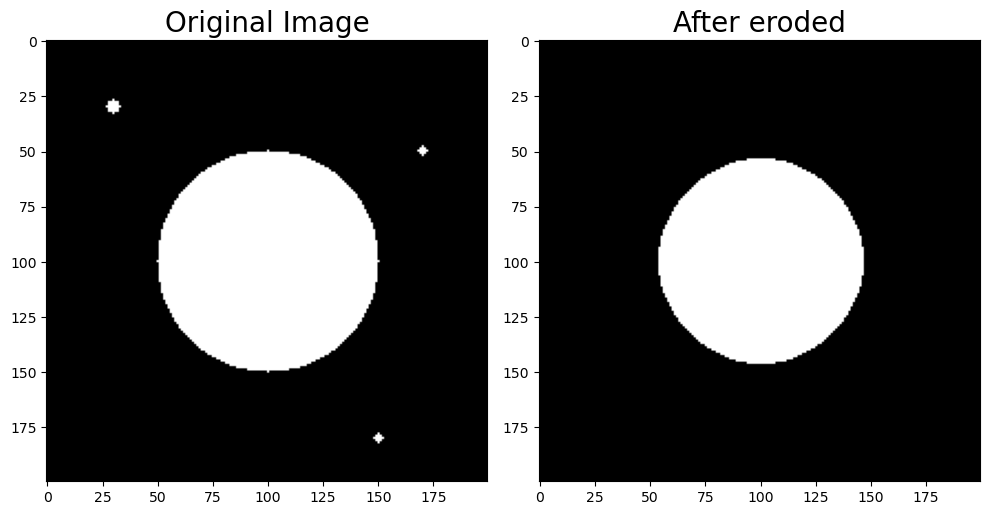

In [14]:
# 產生一張全黑背景的影像 
img = np.zeros((200, 200), dtype=np.uint8) 

# 畫一個白色實心圓（模擬主要物件） 
cv2.circle(img, (100, 100), 50, 255, -1)

# 加入幾個小白點（模擬雜點） 
cv2.circle(img, (30, 30), 3, 255, -1) 
cv2.circle(img, (170, 50), 2, 255, -1) 
cv2.circle(img, (150, 180), 2, 255, -1) 

# 建立 7x7 方形結構元素
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7)) 

# 執行侵蝕運算 
eroded = cv2.erode(img, kernel, iterations=1) 

opencv_tools.show_img_by_matplotlib_1x2(
    'Original Image', img,
    'After eroded', eroded    
)

## 10-3-2 程式範例：影像膨脹

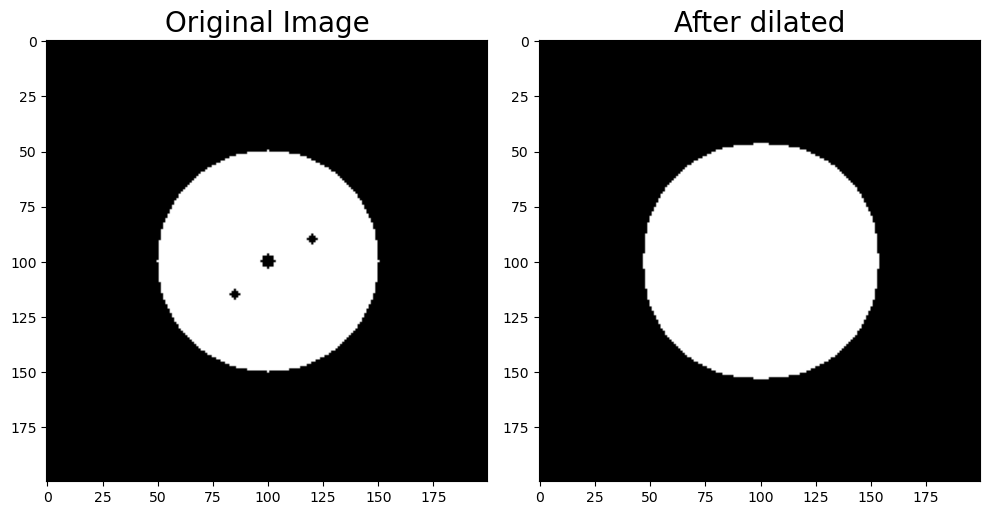

In [15]:
# 產生一張全黑背景的影像
img = np.zeros((200, 200), dtype=np.uint8)

# 畫一個白色實心圓（模擬主要物件）
cv2.circle(img, (100, 100), 50, 255, -1)

# 加入幾個小黑點（模擬雜點）
cv2.circle(img, (100, 100), 3, 0, -1) # 圓心的小黑洞
cv2.circle(img, (120, 90), 2, 0, -1)  # 旁邊的小黑洞
cv2.circle(img, (85, 115), 2, 0, -1)  # 另一個小黑洞

# 建立 7x7 方形結構元素
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))

# 執行膨脹運算
dilated = cv2.dilate(img, kernel, iterations=1)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x2(
    'Original Image', img,
    'After dilated', dilated    
)

### 10-4-2 程式範例：透過「開運算」去除雜訊

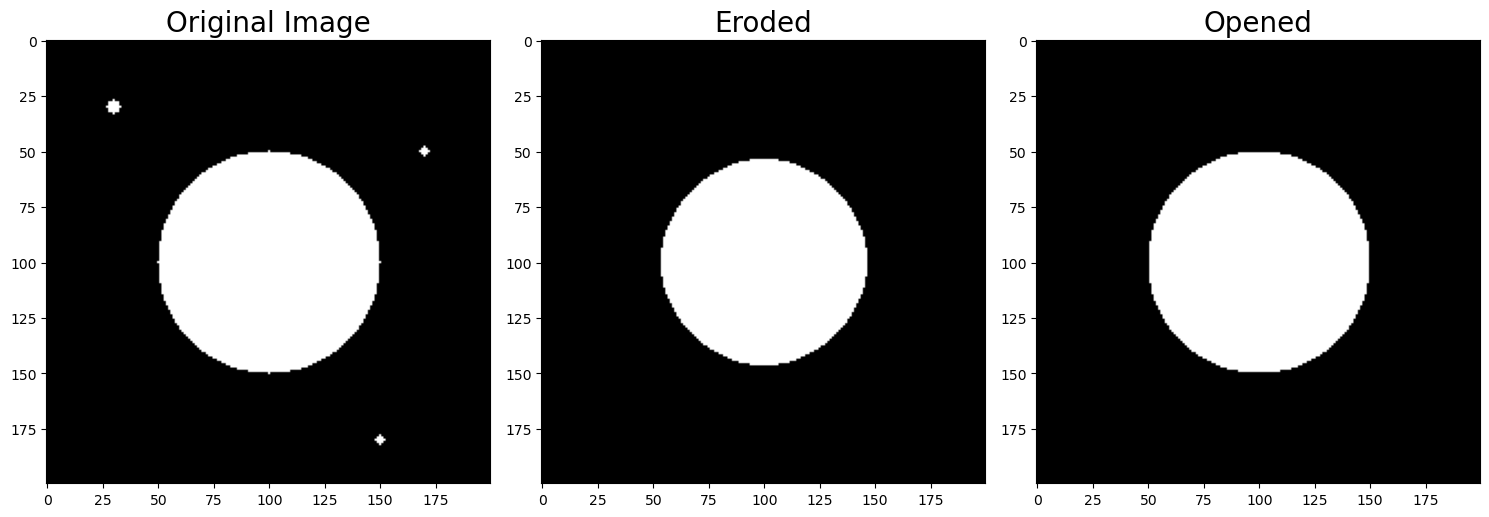

In [16]:
# 產生一張全黑背景的影像 
img = np.zeros((200, 200), dtype=np.uint8) 

# 畫一個白色實心圓（模擬主要物件） 
cv2.circle(img, (100, 100), 50, 255, -1)

# 加入幾個小白點（模擬雜點） 
cv2.circle(img, (30, 30), 3, 255, -1) 
cv2.circle(img, (170, 50), 2, 255, -1) 
cv2.circle(img, (150, 180), 2, 255, -1) 

# 建立 7x7 方形結構元素
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7)) 

# 執行開運算（先侵蝕再膨脹）
opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Original Image', img,
    'Eroded', eroded,    
    'Opened', opened    
)

### 10-4-3 程式範例：透過「閉運算」填補小洞

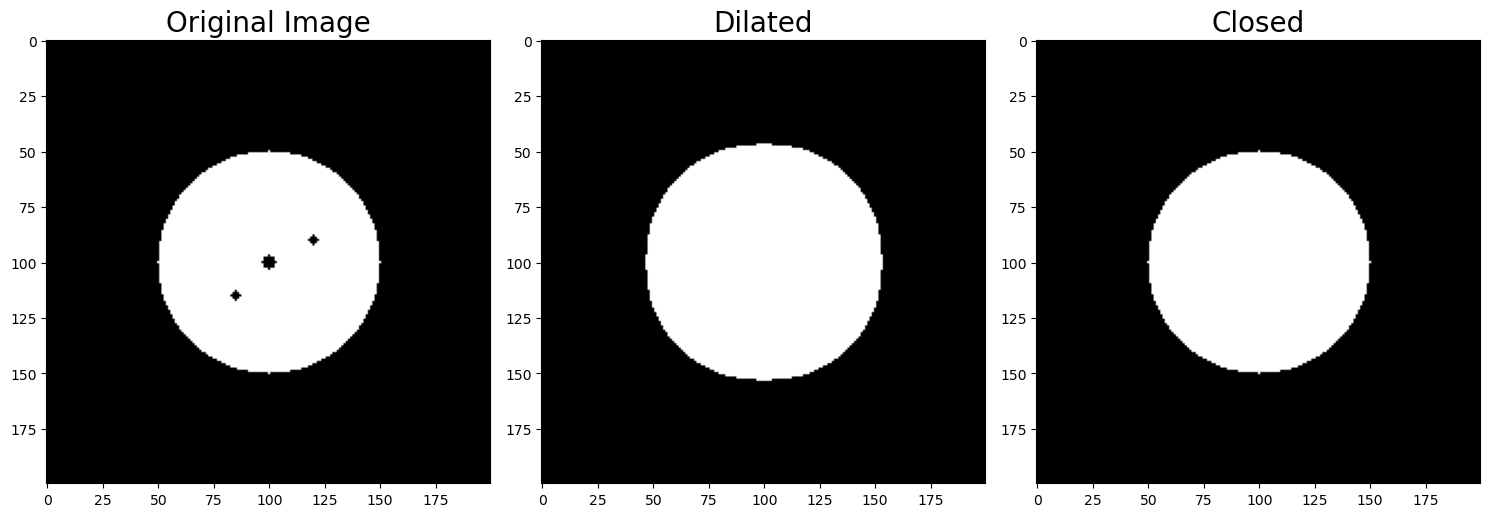

In [17]:
# 產生一張全黑背景的影像
img = np.zeros((200, 200), dtype=np.uint8)

# 畫一個白色實心圓（模擬主要物件）
cv2.circle(img, (100, 100), 50, 255, -1)

# 加入幾個小黑點（模擬雜點）
cv2.circle(img, (100, 100), 3, 0, -1) # 圓心的小黑洞
cv2.circle(img, (120, 90), 2, 0, -1)  # 旁邊的小黑洞
cv2.circle(img, (85, 115), 2, 0, -1)  # 另一個小黑洞

# 建立 7x7 方形結構元素
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))

# 執行閉運算（先膨脹再侵蝕）
closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Original Image', img,
    'Dilated', dilated,    
    'Closed', closed    
)

### 10-4-4 補充：透過「形態學梯度」突顯物體邊界

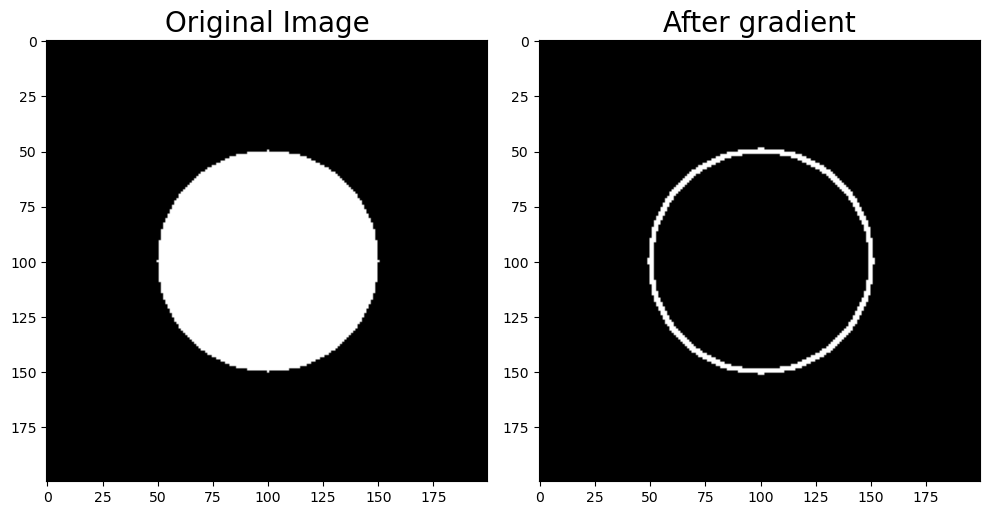

In [18]:
# 建立一張全黑影像
img = np.zeros((200, 200), dtype=np.uint8)

# 畫一個大白圓（模擬主要物件）
cv2.circle(img, (100, 100), 50, 255, -1)

# 建立 3x3 方形結構元素
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# 執行形態學梯度運算
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x2(
    'Original Image', img,
    'After gradient', gradient    
)

### 10-4-5 補充：找出細微亮處的「頂帽運算」

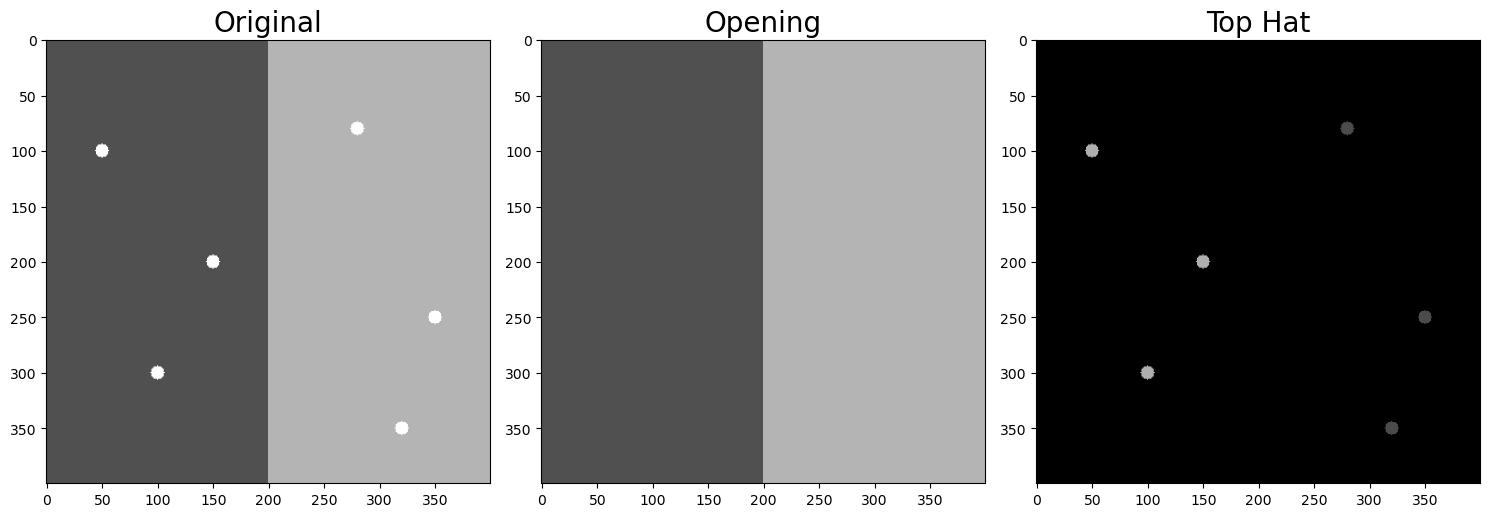

In [19]:
# ===== 步驟 1：繪製範例圖 =====
img = np.zeros((400, 400), dtype=np.uint8)
# 左半部偏暗（陰影區）、右半部偏亮（照光區）
img[:, :200] = 80
img[:, 200:] = 180

# 散佈小亮點（要被頂帽挑出來的目標）
spots = [(50, 100), (100, 300), (150, 200),   # 暗區的亮點
         (280, 80), (350, 250), (320, 350)]    # 亮區的亮點
for pt in spots:
    cv2.circle(img, pt, 6, 255, -1)

# ===== 步驟 2：執行頂帽運算 =====
# 建立結構元素
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
# 開運算：消除小亮點，只留下大面積的亮區
opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
# 頂帽運算：原影像 - 開運算結果
tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)

# ===== 步驟 3：顯示結果 =====
opencv_tools.show_img_by_matplotlib_1x3(
    'Original', img,
    'Opening', opened,
    'Top Hat', tophat,
)

### 10-4-6 補充：找出細微暗處的「黑帽運算」

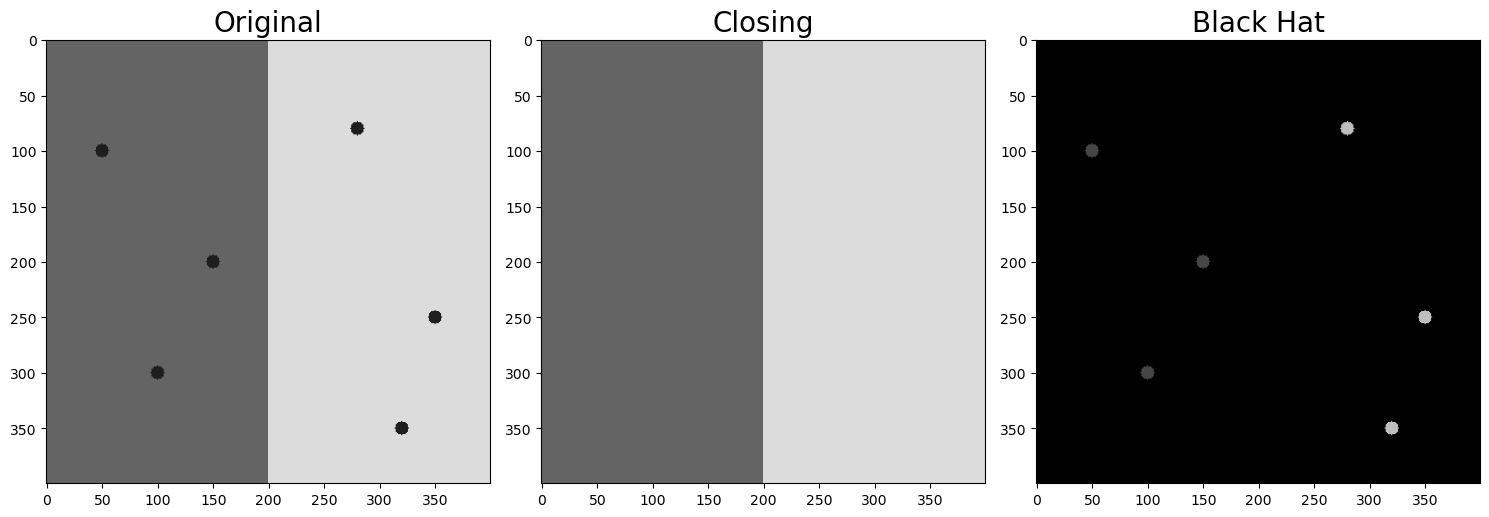

In [20]:
# ===== 步驟 1：繪製範例圖 =====
img = np.zeros((400, 400), dtype=np.uint8)
# 左半部偏暗、右半部偏亮（與頂帽範例一致）
img[:, :200] = 100
img[:, 200:] = 220

# 散佈小暗點（要被黑帽挑出來的目標）
spots = [(50, 100), (100, 300), (150, 200),   # 暗區的暗點
         (280, 80), (350, 250), (320, 350)]    # 亮區的暗點
for pt in spots:
    cv2.circle(img, pt, 6, 30, -1)

# ===== 步驟 2：執行黑帽運算 =====
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

# ===== 步驟 3：顯示結果 =====
opencv_tools.show_img_by_matplotlib_1x3(
    'Original', img,
    'Closing', closed,
    'Black Hat', blackhat,
)

## 10-E-1 程式範例：將二值化後的車牌進行優化處理

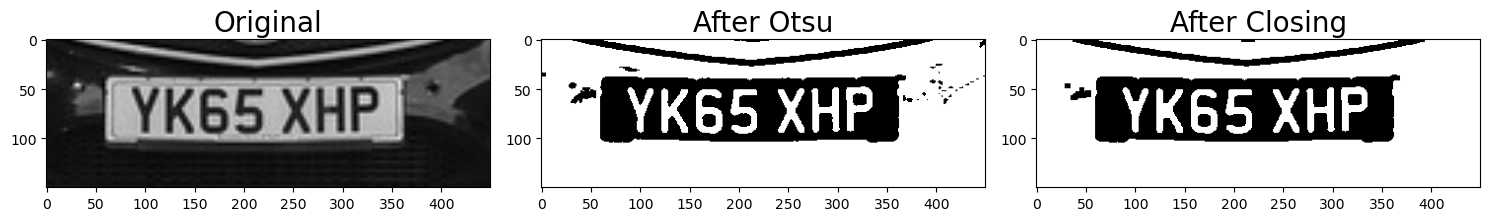

In [21]:
# 讀取影像
img = cv2.imread('sample/car.jpg')

# 轉灰階影像
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 模仿車牌偵測的結果，擷取車牌部分
license_plate = img_gray[275:325,250:400]

# 由於擷取後的圖片太小, 結構元素對於圖片中太大, 這裡我們放大一下
license_plate = cv2.resize(license_plate, None, fx=3.0, fy=3.0)  # 長, 寬放大三倍

# Otsu 反向二值化：把暗色文字轉為白色前景，背景轉為黑色
ret, otsu_binary = cv2.threshold(license_plate, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 閉運算：先膨脹後侵蝕，用於填補字體內的斷點或空洞，使字型更完整
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closing = cv2.morphologyEx(otsu_binary, cv2.MORPH_CLOSE, kernel)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(
    "Original", license_plate, 
    "After Otsu", otsu_binary,
    "After Closing", closing
)